In [2]:
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
import seaborn as sns

## 0 Load data

This Notebook is for descriptive temporal analysis only. As no Census Tract values are needed for this, the full dataset `taxi_data_processed_big.parquet` is being used.

In [3]:
taxi_data = pd.read_parquet(
    "../data/processed/taxi_data_processed_big.parquet"
)
taxi_data.info()

<class 'pandas.DataFrame'>
Index: 12949755 entries, 419224 to 16086254
Data columns (total 22 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   Trip ID                     str           
 1   Taxi ID                     str           
 2   Trip Start Timestamp        datetime64[us]
 3   Trip End Timestamp          datetime64[us]
 4   Trip Seconds                float64       
 5   Trip Miles                  float64       
 6   Pickup Census Tract         float64       
 7   Dropoff Census Tract        float64       
 8   Pickup Community Area       float64       
 9   Dropoff Community Area      float64       
 10  Trip Total                  float64       
 11  Company                     str           
 12  Pickup Centroid Latitude    float64       
 13  Pickup Centroid Longitude   float64       
 14  Dropoff Centroid Latitude   float64       
 15  Dropoff Centroid Longitude  float64       
 16  h3_index_pickup_7          

## 1 Data Preparation

All spatial features were dropped from the dataset as they are not needed for temporal analysis.


In [4]:
#drop all spatial columns as they are not needed for temporal analysis
taxi_data = taxi_data.drop(columns=["Pickup Census Tract", "Dropoff Census Tract", 
                                    "Pickup Community Area", "Dropoff Community Area", 
                                    "h3_index_pickup_7", "h3_index_dropoff_7",
                                    "h3_index_pickup_8", "h3_index_dropoff_8",
                                    "h3_index_pickup_9", "h3_index_dropoff_9",
                                    "Pickup Centroid Latitude", "Dropoff Centroid Latitude",
                                    "Pickup Centroid Longitude", "Dropoff Centroid Longitude"])

In [5]:
#convert to datetime
taxi_data["Trip Start Timestamp"] = pd.to_datetime(
    taxi_data["Trip Start Timestamp"]
)

taxi_data["Trip End Timestamp"] = pd.to_datetime(
    taxi_data["Trip End Timestamp"]
)

#convert to Dollar ($)
taxi_data["Trip Total"] = taxi_data["Trip Total"]/100

For a detailed analysis further features were created, including multiple temporal features, trip duration and average speed.

In [6]:
#create temporal features
taxi_data["date"] = taxi_data["Trip Start Timestamp"].dt.date
taxi_data["year"] = taxi_data["Trip Start Timestamp"].dt.year

taxi_data["month"] = taxi_data["Trip Start Timestamp"].dt.month

taxi_data["week"] = taxi_data["Trip Start Timestamp"].dt.isocalendar().week
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
taxi_data["weekday_name"] = pd.Categorical(taxi_data["Trip Start Timestamp"].dt.day_name(), categories=weekday_order, ordered=True)
taxi_data["is_weekend"] = taxi_data["weekday_name"].isin(["Saturday", "Sunday"])

taxi_data["hour"] = taxi_data["Trip Start Timestamp"].dt.hour

#trip duration in minutes
taxi_data["Trip Minutes"] = taxi_data["Trip Seconds"] / 60

#average speed (mph)
taxi_data["average_speed"] = taxi_data["Trip Miles"] / (taxi_data["Trip Minutes"] / 60)

taxi_data

,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Trip Total,Company,date,year,month,week,weekday_name,is_weekend,hour,Trip Minutes,average_speed
419224,f8fea85b104328e0e5fba534e8122c604059b9c1,282f6fefb5261b5b2642a9b4702b76641a0badbd14f304...,2026-05-12 23:00:00,2026-05-12 23:15:00,227.000,0.71,6.05,Taxicab Insurance Agency Llc,2026-05-12,2026,5,20,Tuesday,False,23,3.783333,11.259912
419225,5f1e1a49e66d2614f66d5fec279cbf8816a0d63a,b9a58663518c48b09e83f462ca25ee0d702a2e4bc12199...,2026-05-12 23:00:00,2026-05-12 23:15:00,1.383,13.10,50.70,City Service,2026-05-12,2026,5,20,Tuesday,False,23,0.023050,34099.783080
419227,6a6b8cc9175e215b66a0cf1d4e36b0d17b5cd472,9dc2e0578dc153302955faa509065c083d18c91767f762...,2026-05-12 23:00:00,2026-05-12 23:00:00,7.000,0.01,90.60,Medallion Leasin,2026-05-12,2026,5,20,Tuesday,False,23,0.116667,5.142857
419229,991144777adda9e226725a64de96761099911d97,ae31f2151e8b85c5c1981e09c227aa451a6fda9b739d63...,2026-05-12 23:00:00,2026-05-12 23:00:00,422.000,1.04,8.28,Blue Ribbon Taxi Association,2026-05-12,2026,5,20,Tuesday,False,23,7.033333,8.872038
419230,4a529df21c852c6c77d4d20bbb4844227bfe490c,2d4235dd5d044ce0a67f57c2879eb279055ac8da29b733...,2026-05-12 23:00:00,2026-05-12 23:15:00,1.380,16.20,54.70,Transit Administrative Center Inc,2026-05-12,2026,5,20,Tuesday,False,23,0.023000,42260.869565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16086248,979a99625daee328ef36e2858f655f09e736c0a5,8f35ce7248373090931a3261c8da3d73ebc5b81bd4546d...,2024-01-01 00:00:00,2024-01-01 00:30:00,2.040,21.31,58.25,Sun Taxi,2024-01-01,2024,1,1,Monday,False,0,0.034000,37605.882353
16086250,fc08277cee8647cb9a4eb700da02ce287029ca2a,3618045f9110d4d88482266ade23659c1a50d32ac37f20...,2024-01-01 00:00:00,2024-01-01 00:15:00,840.000,7.10,20.25,Taxi Affiliation Services,2024-01-01,2024,1,1,Monday,False,0,14.000000,30.428571
16086252,bdc420394ce5e864465df0a361dfbe95a4e228c4,389f01c14b097ed951468ff163ccc71ebcb99a27e523e9...,2024-01-01 00:00:00,2024-01-01 00:30:00,1.369,3.07,26.00,Medallion Leasin,2024-01-01,2024,1,1,Monday,False,0,0.022817,8073.046019
16086253,70679bacef2403edfa376cd42f2b04037e7534c1,8123ec5a70681a139fcd93fd477eec0ee05dda82987748...,2024-01-01 00:00:00,2024-01-01 00:15:00,584.000,0.43,7.75,Globe Taxi,2024-01-01,2024,1,1,Monday,False,0,9.733333,2.650685


## 2. Overall Demand

This section provides an overview of the overall temporal development of taxi demand throughout the observation period. Daily and weekly trip counts are analyzed to identify long-term trends, recurring patterns, and potential anomalies in the data.

### 2.1 Daily Demand

In [7]:
# Number of trips per day
daily_demand = (
    taxi_data
    .groupby("date")
    .size()
    .rename("trip_count")
    .reset_index()
)

daily_demand

,date,trip_count
0,2024-01-01,7471
1,2024-01-02,10239
2,2024-01-03,11009
3,2024-01-04,11200
4,2024-01-05,10451
...,...,...
858,2026-05-08,19175
859,2026-05-09,14684
860,2026-05-10,13773
861,2026-05-11,16561


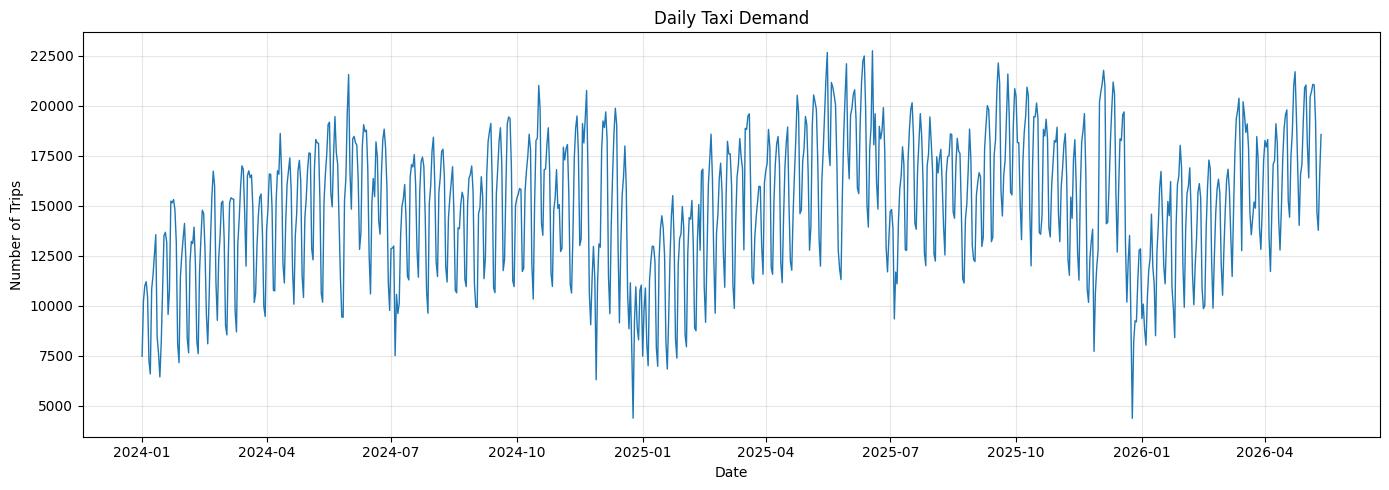

In [28]:
plt.figure(figsize=(14,5))

plt.plot(
    daily_demand["date"],
    daily_demand["trip_count"],
    linewidth=1
)

plt.title("Daily Taxi Demand")
plt.xlabel("Date")
plt.ylabel("Number of Trips")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"../plots/daily_taxi_demand.png", dpi=150)
plt.show()

The daily number of taxi trips exhibits a pronounced weekly cycle. Demand regularly increases and decreases at approximately seven-day intervals, indicating systematic differences between weekdays and weekends.

Beyond this weekly pattern, the overall demand shows moderate long-term fluctuations. Demand is generally lower at the beginning of 2024, increases towards mid-2024, decreases again around the turn of the year 2024/2025, and rises afterwards.

Several days exhibit unusually low trip counts. These may correspond to public holidays, extreme weather events, data collection issues, or incomplete observations. The final observation with zero trips is most likely caused by an incomplete recording of the last day and should therefore not be interpreted as an actual demand pattern.

### 2.2 Weekly Demand

In [29]:
weekly_demand = (
    taxi_data
    .groupby(["year", "week"])
    .size()
    .rename("trip_count")
    .reset_index()
)

weekly_demand["year_week"] = (
    weekly_demand["year"].astype(str)
    + "-W"
    + weekly_demand["week"].astype(str).str.zfill(2)
)

weekly_demand

,year,week,trip_count,year_week
0,2024,1,86022,2024-W01
1,2024,2,70966,2024-W02
2,2024,3,79782,2024-W03
3,2024,4,88891,2024-W04
4,2024,5,79724,2024-W05
...,...,...,...,...
119,2026,16,120167,2026-W16
120,2026,17,128992,2026-W17
121,2026,18,129207,2026-W18
122,2026,19,130915,2026-W19


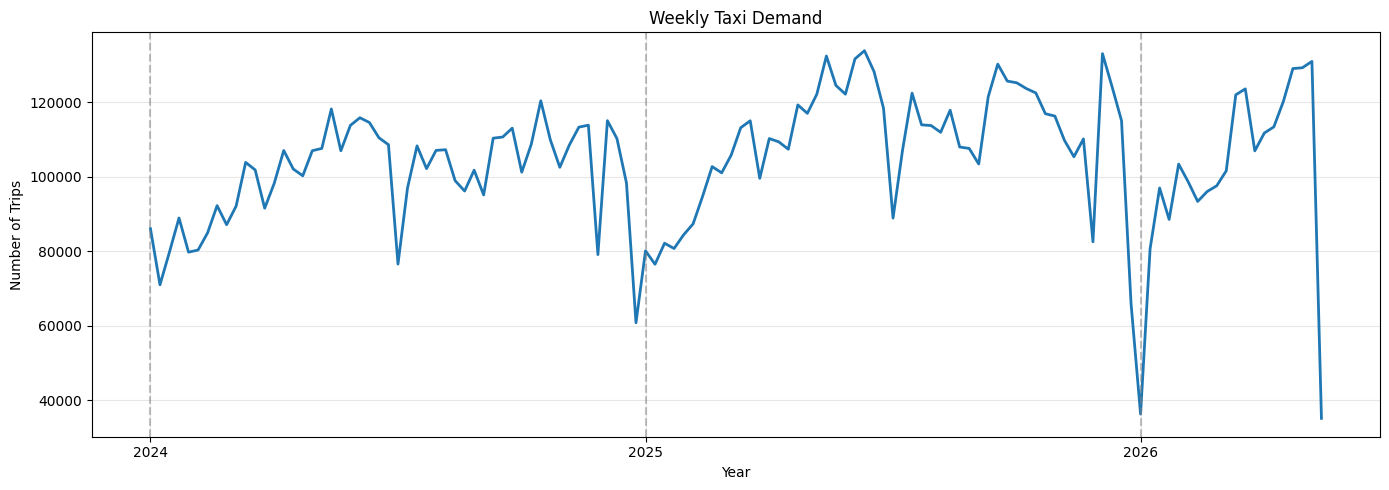

In [30]:
# Position of the first week of each year
year_start_positions = (
    weekly_demand
    .groupby("year")
    .head(1)
    .index
)

year_labels = (
    weekly_demand
    .groupby("year")
    .head(1)["year"]
)

plt.figure(figsize=(14,5))
plt.plot(
    weekly_demand.index,
    weekly_demand["trip_count"],
    linewidth=2
)

# Mark the beginning of each year
for pos in year_start_positions:
    plt.axvline(pos, color="grey", linestyle="--", alpha=0.5)

plt.xticks(
    year_start_positions,
    year_labels
)

plt.title("Weekly Taxi Demand")
plt.xlabel("Year")
plt.ylabel("Number of Trips")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Aggregating demand on a weekly basis removes most of the short-term fluctuations and highlights broader temporal trends. Weekly demand varies between approximately 80,000 and 145,000 trips.

Demand decreases noticeably around the beginning of each year before recovering in the following months. Such recurring reductions are likely related to seasonal effects, for example lower travel activity during holiday periods.

The sharp decline in the final week is caused by an incomplete week, as the data was cut on a Tuesday.

## 3 Intraday patterns

This section examines how taxi demand varies within a typical day. The analysis focuses on hourly demand patterns, differences between weekdays and weekends, and variations across individual weekdays to identify recurring temporal mobility patterns.

### 3.1 Demand by Hour of the Day

In [31]:
hourly_demand = taxi_data.groupby("hour").size()
weekly_demand = taxi_data.groupby("weekday_name").size()

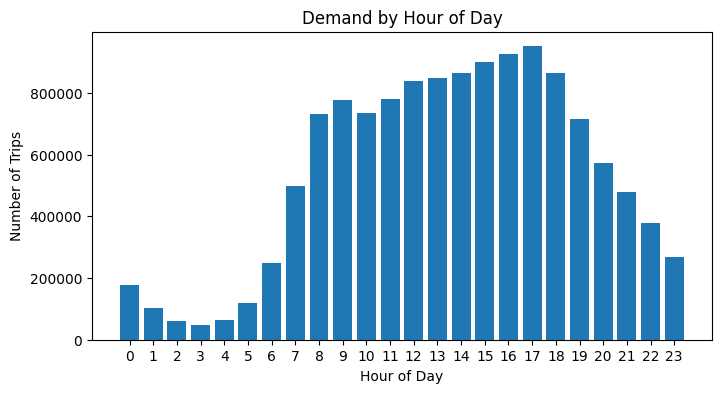

In [32]:
plt.figure(figsize=(8, 4))
plt.bar(hourly_demand.index, hourly_demand.values)

plt.title("Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.savefig(f"../plots/hourly_demand_bar.png", dpi=150)
plt.show()

The observed pattern reflects typical daily mobility behaviour. Demand is lowest during the early morning hours when most people are inactive. Beginning with the morning commute, demand increases rapidly and remains high throughout normal business hours. The peak in the late afternoon is likely associated with commuters returning home as well as increased leisure activities after work.

### 3.2 Weekday vs Weekend

In [33]:
hourly_weekend = (
    taxi_data.groupby(["date", "hour", "is_weekend"])
    .size()
    .reset_index(name="trips")
)

hourly_weekend_avg = (
    hourly_weekend
    .groupby(["hour", "is_weekend"])["trips"]
    .mean()
    .unstack()
)

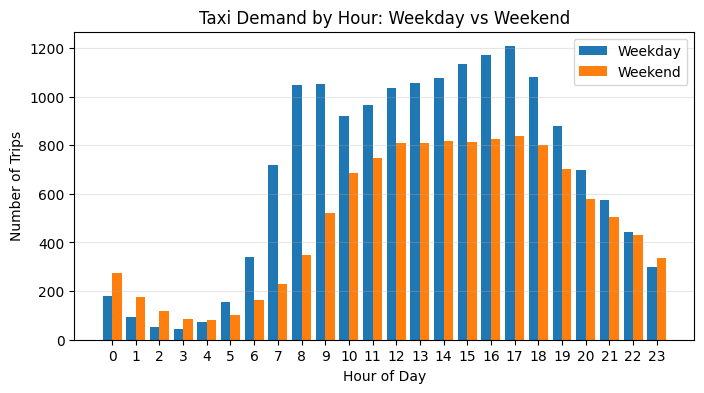

In [34]:
hours = hourly_weekend_avg.index

x = np.arange(len(hours))
width = 0.4

plt.figure(figsize=(8,4))

plt.bar(
    x - width/2,
    hourly_weekend_avg[False],
    width,
    label="Weekday"
)

plt.bar(
    x + width/2,
    hourly_weekend_avg[True],
    width,
    label="Weekend"
)

plt.xticks(x, hours)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Taxi Demand by Hour: Weekday vs Weekend")

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.savefig(f"../plots/hourly_demand_weekday_weekend.png", dpi=150)
plt.show()

Weekdays exhibit pronounced morning and evening peaks, indicating commuting behaviour during regular working hours. In contrast, weekends show substantially higher demand during the night and early morning, suggesting increased leisure and nightlife-related travel. The absence of a strong morning peak further reflects the reduced importance of work-related trips on weekends.

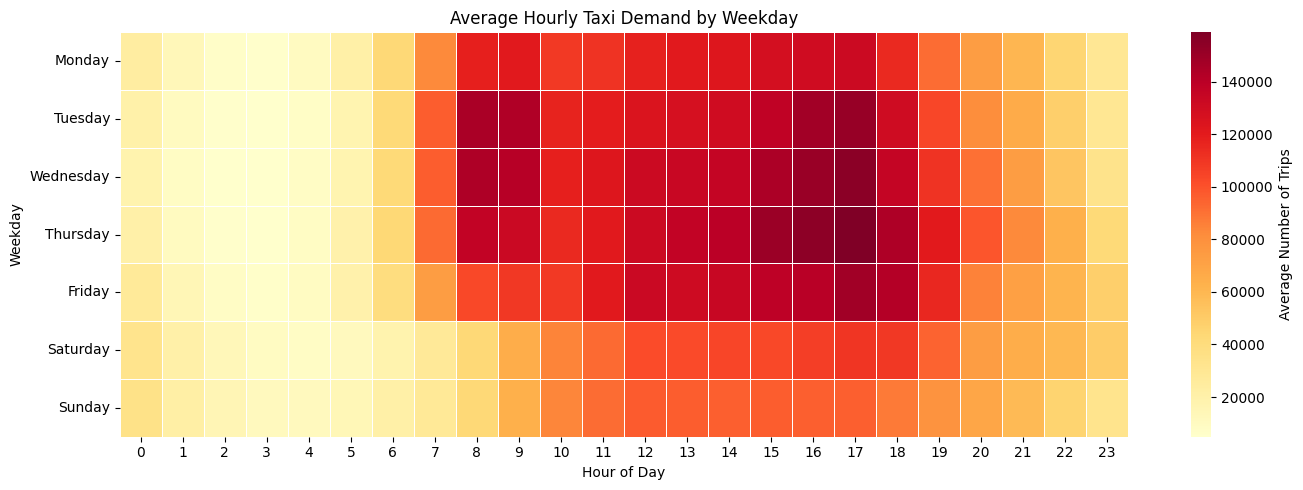

In [35]:
# Average hourly demand for each weekday
heatmap_data = (
    taxi_data
    .groupby(["weekday_name", "hour"])
    .size()
    .groupby(level=[0, 1])
    .mean()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 5))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Average Number of Trips"}
)

plt.title("Average Hourly Taxi Demand by Weekday")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday")

plt.tight_layout()
plt.show()

The heatmap highlights highly regular intraday demand patterns across all weekdays. Demand is consistently lowest during the early morning hours and increases rapidly after approximately 6 a.m. From Tuesday to Friday, demand remains at a particularly high level throughout the working day, reaching its maximum during the late afternoon. In contrast, Saturdays and Sundays exhibit a noticeably weaker morning peak and a flatter demand profile, reflecting reduced commuter traffic and increased leisure-oriented travel.

## 4 Trip Characteristics over Time

This section examines how the characteristics of taxi trips change throughout the day. Besides overall demand, variations in trip distance, travel speed, and fare per mile provide insights into changing travel behavior, traffic conditions, and pricing patterns. Finally, the temporal variability of key features is compared using the coefficient of variation.

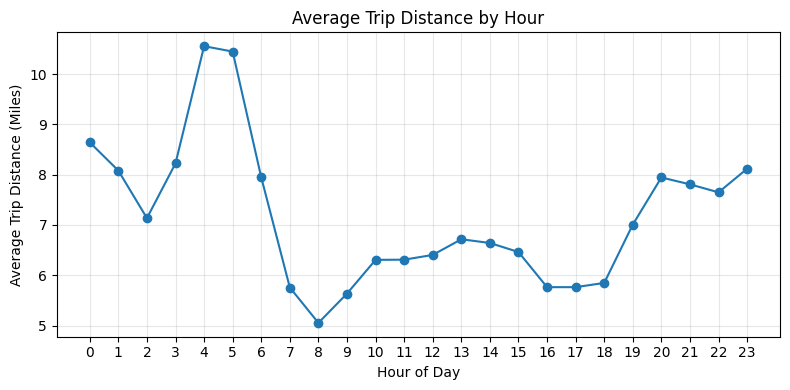

In [36]:
hourly_trip_distance = (
    taxi_data
    .groupby("hour")["Trip Miles"]
    .mean()
)

plt.figure(figsize=(8,4))

plt.plot(
    hourly_trip_distance.index,
    hourly_trip_distance.values,
    marker="o"
)

plt.title("Average Trip Distance by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Trip Distance (Miles)")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"../plots/hourly_tripdistance.png", dpi=150)
plt.show()

Average trip distance is highest during the early morning hours between approximately 4:00 and 5:00, reaching more than 10 miles per trip. During the morning commute, the average distance decreases substantially and remains relatively stable between 6 and 7 miles throughout most of the day. Distances increase again during the late evening.

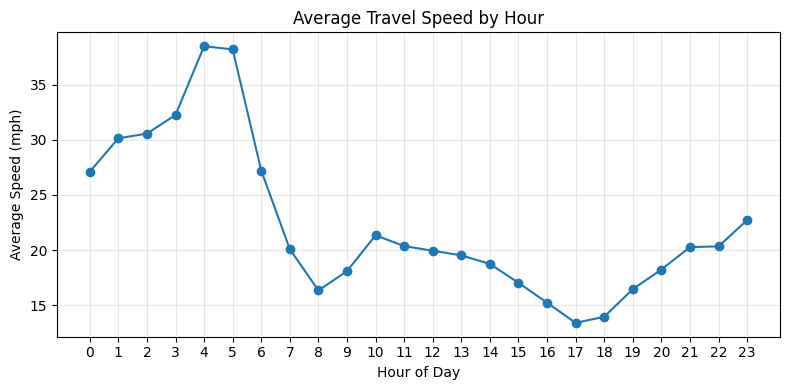

In [37]:
speed_data = taxi_data[(taxi_data["Trip Seconds"] >= 10)].copy()

hourly_speed = (
    speed_data
    .groupby("hour")["average_speed"]
    .mean()
)

plt.figure(figsize=(8,4))

plt.plot(
    hourly_speed.index,
    hourly_speed.values,
    marker="o"
)

plt.title("Average Travel Speed by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Speed (mph)")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"../plots/hourly_demand_speed.png", dpi=150)
plt.show()

Average travel speed follows a pattern similar to trip distance. Higher speeds are observed during early morning when road congestion is minimal, whereas speeds decrease considerably during daytime, particularly around the morning commute and the early evening. The similarity between both curves suggests that longer trips mainly occur during periods with lower traffic density.

In [38]:
taxi_data["fare_per_mile"] = (
    taxi_data["Trip Total"] /
    taxi_data["Trip Miles"]
)

taxi_data.loc[
    taxi_data["Trip Miles"] < 0.1,
    "fare_per_mile"
] = np.nan

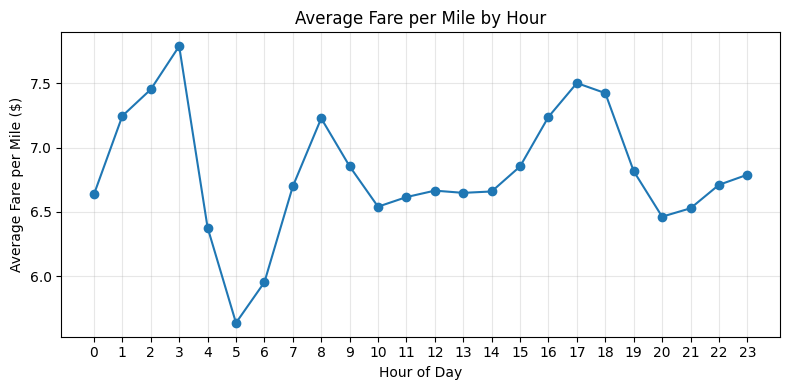

In [39]:
hourly_fare_per_mile = (
    taxi_data
    .groupby("hour")["fare_per_mile"]
    .mean()
)

plt.figure(figsize=(8,4))

plt.plot(
    hourly_fare_per_mile.index,
    hourly_fare_per_mile.values,
    marker="o"
)

plt.title("Average Fare per Mile by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare per Mile ($)")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"../plots/hourly_demand_fare.png", dpi=150)
plt.show()

The average fare per mile shows considerably less variation over time. While moderate increases are visible during the morning and evening rush hours, the overall range remains relatively small compared with the changes observed for trip distance and travel speed. This indicates that pricing per mile remains relatively stable despite changing traffic conditions.

To quantify the temporal variability, the coefficient of variation (CV) was computed for each metric.

In [40]:
hourly_features = (
    taxi_data
    .groupby("hour")
    .agg(
        demand=("Trip ID", "count"),
        trip_distance=("Trip Miles", "mean"),
        speed=("average_speed", "mean"),
        fare_per_mile=("fare_per_mile", "mean"),
    ))

cv = (
    hourly_features.std() /
    hourly_features.mean()
).sort_values(ascending=False)

display(
    cv.rename("Coefficient of Variation")
      .to_frame()
      .style
      .format("{:.3f}")
      .background_gradient(cmap="Blues")
)

,Coefficient of Variation
demand,0.605
speed,0.324
trip_distance,0.199
fare_per_mile,0.072


The results show that taxi demand exhibits by far the strongest temporal variation, whereas fare per mile remains comparatively stable throughout the day. Travel speed shows moderate variation, reflecting changing congestion levels, while average trip distance varies less strongly and follows a relatively smooth daily pattern. Overall, the analysis suggests that temporal demand fluctuations are substantially larger than changes in trip characteristics.

## 5 Relationships between Variables

To better understand the interaction between demand and trip characteristics, the relationships between the aggregated hourly variables are examined using a correlation analysis. This provides insight into how changes in demand, travel speed, trip distance, and fare per mile are associated over the course of the day.

In [41]:
hourly_features = (
    taxi_data
    .groupby("hour")
    .agg(
        demand=("Trip ID", "count"),
        avg_trip_distance=("Trip Miles", "mean"),
        avg_fare_per_mile=("fare_per_mile", "mean"),
    )
)

hourly_speed = (
    speed_data
    .groupby("hour")["average_speed"]
    .mean()
)

hourly_features = hourly_features.join(hourly_speed)
corr = hourly_features.corr(numeric_only=True)

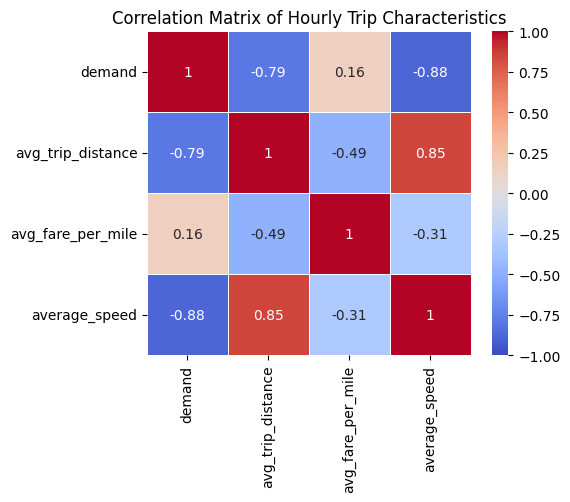

In [42]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Hourly Trip Characteristics")
plt.tight_layout()
plt.savefig(f"../plots/hourly_demand_correlation.png", dpi=150)
plt.show()

The correlation matrix summarizes the relationships between the hourly demand and the analyzed trip characteristics.

As expected, taxi demand exhibits a strong negative correlation with average travel speed (-0.88). During periods of high demand, particularly the morning and evening rush hours, increased traffic congestion leads to lower average travel speeds.

A similarly strong negative correlation is observed between demand and average trip distance (-0.79). Longer trips occur primarily during periods of lower demand, such as nighttime and the early morning, whereas daytime demand is dominated by shorter urban trips.

Average travel speed and average trip distance show a strong positive correlation (0.85). This indicates that longer trips are generally completed during periods with less congestion, allowing for higher average speeds.

In contrast, fare per mile is only weakly correlated with the remaining variables. Its correlation with demand is close to zero (0.16), suggesting that pricing per mile remains relatively stable throughout the day despite substantial fluctuations in demand and traffic conditions.

Overall, the analysis indicates that temporal changes in demand are primarily associated with changes in traffic conditions and trip characteristics, while the pricing structure remains comparatively consistent over time.

## 6 Average Idle Time Between Trips

In addition to demand and trip characteristics, the time between consecutive trips provides insight into taxi utilization throughout the day. Since the dataset does not contain information about driver shifts or vehicle availability, idle time is approximated using the time between consecutive recorded trips of the same taxi.

In [43]:
idle = (
    taxi_data
    .sort_values(["Taxi ID", "Trip Start Timestamp"])
    .copy()
)

idle["next_trip_start"] = (
    idle.groupby("Taxi ID")["Trip Start Timestamp"].shift(-1)
)

idle["idle_minutes"] = (
    idle["next_trip_start"] -
    idle["Trip End Timestamp"]
).dt.total_seconds() / 60

idle = idle[idle["idle_minutes"] >= 0].copy()

In [44]:
idle["idle_minutes"].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

count    1.273152e+07
mean     2.510044e+02
std      2.273964e+03
min      0.000000e+00
25%      1.500000e+01
50%      3.000000e+01
75%      1.200000e+02
90%      8.250000e+02
95%      1.110000e+03
99%      2.595000e+03
max      1.075050e+06
Name: idle_minutes, dtype: float64

In [45]:
idle["hour_next_start"] = idle["next_trip_start"].dt.hour

hourly_idle = (
    idle[idle["idle_minutes"] >= 0]
    .groupby("hour_next_start")["idle_minutes"]
    .agg(["mean", "median"])
)

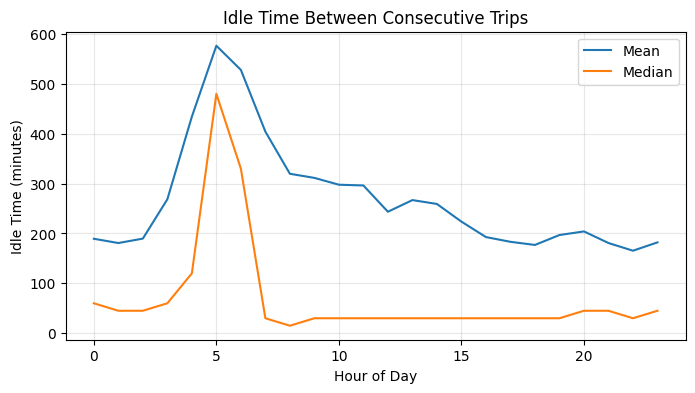

In [46]:
plt.figure(figsize=(8,4))

plt.plot(hourly_idle.index, hourly_idle["mean"], label="Mean")
plt.plot(hourly_idle.index, hourly_idle["median"], label="Median")

plt.xlabel("Hour of Day")
plt.ylabel("Idle Time (minutes)")
plt.title("Idle Time Between Consecutive Trips")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

The average idle time between consecutive trips exhibits substantial temporal variation. However, the distribution of idle times is highly right-skewed, with a median of only 30 minutes but a mean of approximately 246 minutes. This discrepancy is caused by a considerable number of very long idle periods between consecutive trips.

The available dataset contains only completed taxi trips and does not include information about driver shifts or periods during which taxis were out of service. Consequently, the calculated idle time includes not only operational waiting time between passengers, but also overnight breaks, shift changes, maintenance periods, and other extended interruptions.

This limitation is particularly visible during the early morning hours, where both the mean and the median increase substantially, indicating that many taxis finish their last trip before a longer period without recorded activity. Therefore, the observed idle times should not be interpreted as the actual waiting time for the next passenger.

To obtain a more representative approximation of operational idle time, a second analysis excludes idle periods longer than four hours. Such long interruptions are more likely to reflect breaks or the end of a driver's shift than normal waiting time between consecutive customer trips.

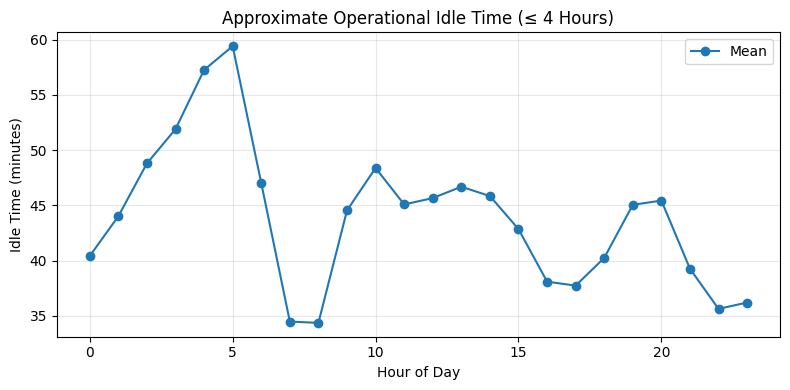

In [47]:
idle_filtered = idle[
    (idle["idle_minutes"] >= 0) &
    (idle["idle_minutes"] <= 240)
].copy()

hourly_idle_filtered = (
    idle_filtered
    .groupby("hour")["idle_minutes"]
    .agg(["mean", "median"])
)

plt.figure(figsize=(8, 4))
plt.plot(
    hourly_idle_filtered.index,
    hourly_idle_filtered["mean"],
    marker="o",
    label="Mean"
)

plt.xlabel("Hour of Day")
plt.ylabel("Idle Time (minutes)")
plt.title("Approximate Operational Idle Time (≤ 4 Hours)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"../plots/idle_time.png", dpi=150)
plt.show()

After filtering, the temporal pattern becomes substantially more stable. Average operational idle times range between approximately 35 and 60 minutes throughout the day. The shortest idle times occur during the morning commuting period, indicating that taxis find their next passenger more quickly when demand is high. Longer idle times are observed during periods of lower demand, particularly during the early morning hours.

The median idle time remains between approximately 15 and 30 minutes throughout most of the day, confirming that the distribution is right-skewed.

Overall, the filtered analysis better reflects the operational availability of taxis than the unfiltered results and is therefore more suitable for assessing the relationship between taxi demand and driver idle time.


## 7 Conclusion

The temporal analysis reveals clear and consistent daily demand patterns in the Chicago taxi dataset. Taxi demand exhibits pronounced morning and evening peaks on weekdays, while weekends show a delayed demand profile with increased nighttime activity. These recurring patterns indicate that travel demand is strongly influenced by commuting behavior and daily routines.

Trip characteristics also vary systematically throughout the day. Higher demand is associated with lower average travel speeds and shorter trip distances, reflecting increased traffic congestion during peak periods. In contrast, fare per mile remains relatively stable, suggesting that pricing is less affected by temporal fluctuations than traffic conditions.

The correlation analysis further confirms these relationships, highlighting a strong negative association between demand and travel speed as well as a strong positive relationship between travel speed and trip distance.

Finally, the analysis of idle time illustrates an important limitation of the dataset. While the raw time between consecutive trips is heavily influenced by overnight breaks and driver shift changes, filtering long interruptions provides a more meaningful approximation of operational idle time. The results indicate that taxis generally experience shorter waiting times during periods of higher demand, reflecting improved vehicle utilization.

Overall, the identified temporal patterns provide valuable insights into demand dynamics and taxi operations. These findings establish a solid foundation for the subsequent predictive analysis by highlighting the temporal factors that are most strongly associated with variations in taxi demand.